In [109]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
train = pd.read_csv('final_train_dataset.csv')
test = pd.read_csv('final_test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("\nTest columns:", test.columns.tolist())

Train shape: (1153, 36)
Test shape: (289, 33)

Train columns: ['id', 'titre', 'prix', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication', 'quartier_encoded', 'log_prix', 'latitude', 'longitude', 'adresse_osm', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km', 'prix_m2', 'nb_pieces_total', 'type_bien', 'has_garage', 'has_jardin', 'has_piscine', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf', 'age_annonce']

Test columns: ['id', 'titre', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication', 'quartier_encoded', 'latitude', 'longitude', 'adresse_osm', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km', 'nb_pieces_total', 

In [111]:
print("\n--- Train info ---")
train.info()
print("\n--- Test info ---")
test.info()
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nMissing values in test:")
print(test.isnull().sum())


--- Train info ---
<class 'pandas.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1153 non-null   int64  
 1   titre                 1153 non-null   str    
 2   prix                  1153 non-null   float64
 3   surface_m2            1153 non-null   float64
 4   nb_chambres           1153 non-null   float64
 5   nb_salons             1153 non-null   float64
 6   nb_sdb                1153 non-null   float64
 7   quartier              1153 non-null   str    
 8   description           1153 non-null   str    
 9   caracteristiques      996 non-null    str    
 10  source                1153 non-null   str    
 11  date_publication      1153 non-null   str    
 12  quartier_encoded      1153 non-null   float64
 13  log_prix              1153 non-null   float64
 14  latitude              1153 non-null   float64
 15  longitude   

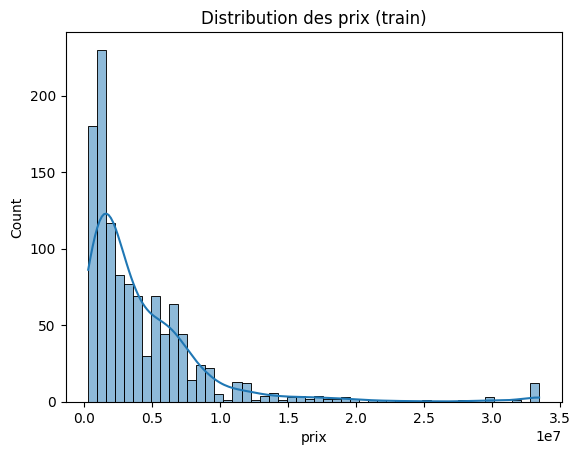

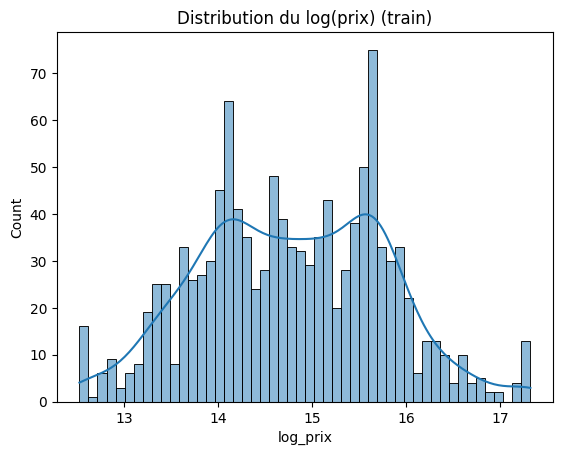

In [112]:
sns.histplot(train['prix'], bins=50, kde=True)
plt.title('Distribution des prix (train)')
plt.show()

# Log-transform pour mieux visualiser
train['log_prix'] = np.log1p(train['prix'])
sns.histplot(train['log_prix'], bins=50, kde=True)
plt.title('Distribution du log(prix) (train)')
plt.show()

Étape 2.1 : Inspection rapide
---------------

In [113]:
# Afficher les premières lignes pour se familiariser
print("Train - aperçu :")
print(train.head())
print("\nTest - aperçu :")
print(test.head())
# Vérifier les dimensions
print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")
# Vérifier les types de données et les valeurs manquantes
print("\n--- Train info ---")
train.info()
print("\n--- Test info ---")
test.info()
# Compter les valeurs manquantes par colonne
print("\nValeurs manquantes dans train :")
print(train.isnull().sum())
print("\nValeurs manquantes dans test :")
print(test.isnull().sum())

Train - aperçu :
     id                                              titre       prix  \
0  1076                    منزل احذ اللنكات حمام الياسمين   1800000.0   
1   875  فرصة دار مكونه من طابقين ارضي و واحد فوقوني كا...  1800000.0   
2   453                               دار فتيارت فاتح فبرك   900000.0   
3   987       دار للبيـــــــــــــــــــــع أفي عين الطلح  1600000.0   
4   252                                        ملح سكتير 2   800000.0   

   surface_m2  nb_chambres  nb_salons  nb_sdb       quartier  \
0       150.0          3.0        2.0     2.0         arafat   
1       300.0          6.0        3.0     2.0  tevragh zeina   
2       216.0          1.0        1.0     2.0       teyarett   
3       150.0          3.0        1.0     2.0       teyarett   
4       180.0          3.0        2.0     2.0     toujounine   

                                         description  \
0  دار للبيع اعل شارع اكبير احذ حمام الياسمين الل...   
1  فرصة دار ، الطابق الأرضي يحتاج ترميم بسبب ال

Étape 2.2 : Analyse de la variable cible (prix) dans le train
--------------------------

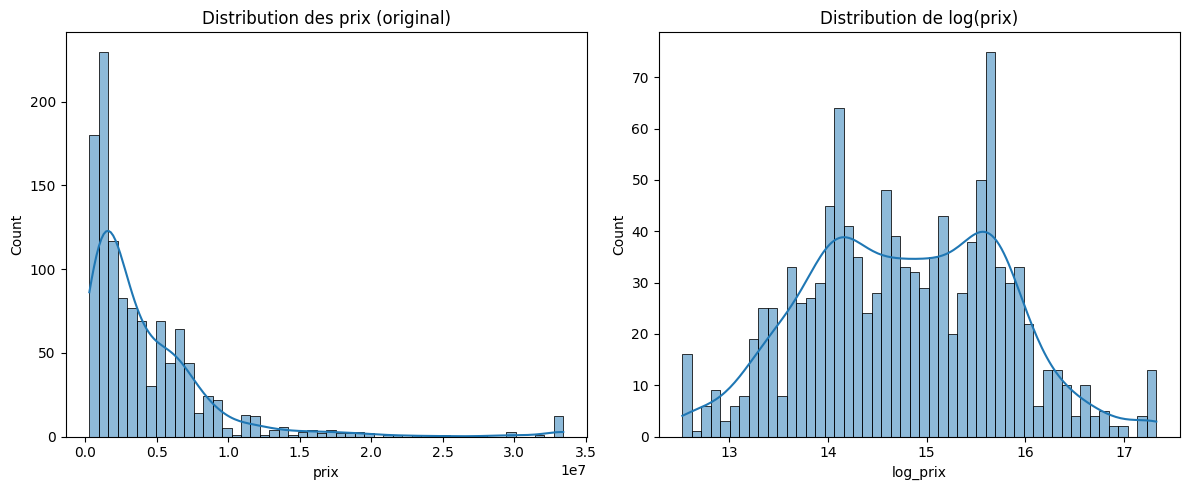

count    1.153000e+03
mean     4.274850e+06
std      4.998663e+06
min      2.752000e+05
25%      1.300000e+06
50%      2.600000e+06
75%      5.800000e+06
max      3.344000e+07
Name: prix, dtype: float64
count    1153.000000
mean       14.787527
std         0.988484
min        12.525257
25%        14.077876
50%        14.771022
75%        15.573369
max        17.325263
Name: log_prix, dtype: float64


In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution du prix
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(train['prix'], bins=50, kde=True)
plt.title('Distribution des prix (original)')

# Log transformation pour mieux gérer l'asymétrie
train['log_prix'] = np.log1p(train['prix'])
plt.subplot(1,2,2)
sns.histplot(train['log_prix'], bins=50, kde=True)
plt.title('Distribution de log(prix)')
plt.tight_layout()
plt.show()

# Statistiques descriptives
print(train['prix'].describe())
print(train['log_prix'].describe())

Étape 2.3 : Séparation des features (X) et de la cible (y)
--------------------------

In [115]:
# Colonnes à exclure (non pertinentes ou sources de fuite de données)
colonnes_a_exclure = ['id', 'titre', 'description', 'caracteristiques', 'source', 'date_publication', 'adresse_osm', 'prix']

# Pour le train, on retire aussi 'prix' (cible) mais on garde 'log_prix' comme cible
X_train = train.drop(columns=colonnes_a_exclure)
y_train = train['log_prix']   # on utilise le log pour la régression

# Pour le test, on retire les mêmes colonnes (sauf 'prix' qui n'existe pas)
X_test = test.drop(columns=[col for col in colonnes_a_exclure if col in test.columns])

print("Features train :", X_train.columns.tolist())
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Features train : ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'quartier_encoded', 'log_prix', 'latitude', 'longitude', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km', 'prix_m2', 'nb_pieces_total', 'type_bien', 'has_garage', 'has_jardin', 'has_piscine', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf', 'age_annonce']
Shape X_train: (1153, 28)
Shape X_test: (289, 26)


Étape 2.4 : Gestion des valeurs manquantes dans les features
---------------------

In [116]:
# --- Correction : s'assurer que les colonnes problématiques sont bien supprimées ---
colonnes_a_supprimer = ['log_prix', 'prix_m2']
for col in colonnes_a_supprimer:
    if col in X_train.columns:
        print(f"Suppression de '{col}' de X_train")
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        print(f"Suppression de '{col}' de X_test")
        X_test = X_test.drop(columns=[col])

# Maintenant, aligner à nouveau les colonnes (au cas où)
train_cols = X_train.columns.tolist()
test_cols = X_test.columns.tolist()

# Ajouter les colonnes manquantes dans test avec des 0
missing_in_test = set(train_cols) - set(test_cols)
for col in missing_in_test:
    X_test[col] = 0

# Supprimer les colonnes en trop dans test
extra_in_test = set(test_cols) - set(train_cols)
if extra_in_test:
    X_test = X_test.drop(columns=extra_in_test)

# Réordonner les colonnes de test selon l'ordre de train
X_test = X_test[train_cols]

# --- Imputation ---
from sklearn.impute import SimpleImputer

# Identifier les colonnes numériques (toutes maintenant)
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print("Colonnes numériques après nettoyage :", numerical_cols)

# Créer et appliquer l'imputeur
imputer = SimpleImputer(strategy='median')
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])

# Vérification
print("NaN dans train après imputation :", X_train.isnull().sum().sum())
print("NaN dans test après imputation :", X_test.isnull().sum().sum())

Suppression de 'log_prix' de X_train
Suppression de 'prix_m2' de X_train
Colonnes numériques après nettoyage : ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier_encoded', 'latitude', 'longitude', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km', 'nb_pieces_total', 'has_garage', 'has_jardin', 'has_piscine', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf', 'age_annonce']
NaN dans train après imputation : 0
NaN dans test après imputation : 0


Étape 2.5 : (Optionnel) Standardisation / Normalisation
---------------------

In [117]:
from sklearn.preprocessing import StandardScaler
def prepare_features(X_train, X_test, colonnes_a_exclure):
    # Suppression
    for col in colonnes_a_exclure:
        if col in X_train.columns:
            X_train = X_train.drop(columns=[col])
        if col in X_test.columns:
            X_test = X_test.drop(columns=[col])
    
    # Alignement
    train_cols = X_train.columns.tolist()
    for col in train_cols:
        if col not in X_test.columns:
            X_test[col] = 0
    X_test = X_test[train_cols]
    
    # Imputation
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
    
    # Standardisation
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    
    return X_train, X_test, imputer, scaler

# Utilisation
colonnes_a_exclure = ['id', 'titre', 'description', 'caracteristiques', 'source', 'date_publication',
                      'adresse_osm', 'prix_m2', 'log_prix', 'quartier', 'type_bien']
X_train, X_test, imputer, scaler = prepare_features(X_train, X_test, colonnes_a_exclure)

Étape 2.6 : Vérification finale
----------

In [118]:
print("Train final shape:", X_train.shape)
print("Test final shape:", X_test.shape)
print("y_train shape:", y_train.shape)

Train final shape: (1153, 24)
Test final shape: (289, 24)
y_train shape: (1153,)


Étape 3.1 : Import des modèles et métriques
-------------------------------

In [119]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
import xgboost as xgb
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

Étape 3.2 : Définition des modèles à tester
------------------------------------

In [120]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

Étape 3.3 : Configuration de la validation croisée
------------------

In [121]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

Étape 3.4 : Boucle d'évaluation de chaque modèle
--------------------------------------

In [122]:
results = []

for name, model in models.items():
    print(f"🔍 Évaluation du modèle : {name}...")
    
    cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring, return_train_score=True)
    
    # Les scores sont négatifs pour rmse et mae, on prend la valeur absolue
    rmse_mean = -cv_results['test_rmse'].mean()
    rmse_std = cv_results['test_rmse'].std()
    mae_mean = -cv_results['test_mae'].mean()
    r2_mean = cv_results['test_r2'].mean()
    
    results.append({
        'Modèle': name,
        'RMSE (moy)': rmse_mean,
        'RMSE (std)': rmse_std,
        'MAE (moy)': mae_mean,
        'R² (moy)': r2_mean
    })
    
    print(f"   ✅ RMSE: {rmse_mean:.4f} (±{rmse_std:.4f}), MAE: {mae_mean:.4f}, R²: {r2_mean:.4f}\n")

# Convertir en DataFrame pour affichage
results_df = pd.DataFrame(results)
print("\n📊 Résultats de la validation croisée :")
print(results_df.to_string(index=False))

🔍 Évaluation du modèle : Linear Regression...
   ✅ RMSE: 0.6595 (±0.0688), MAE: 0.4606, R²: 0.5531

🔍 Évaluation du modèle : Ridge...
   ✅ RMSE: 0.6592 (±0.0693), MAE: 0.4604, R²: 0.5535

🔍 Évaluation du modèle : Lasso...
   ✅ RMSE: 0.6592 (±0.0695), MAE: 0.4605, R²: 0.5535

🔍 Évaluation du modèle : Random Forest...
   ✅ RMSE: 0.6770 (±0.0655), MAE: 0.4735, R²: 0.5290

🔍 Évaluation du modèle : Gradient Boosting...
   ✅ RMSE: 0.6497 (±0.0736), MAE: 0.4478, R²: 0.5656

🔍 Évaluation du modèle : XGBoost...
   ✅ RMSE: 0.6747 (±0.0739), MAE: 0.4672, R²: 0.5314


📊 Résultats de la validation croisée :
           Modèle  RMSE (moy)  RMSE (std)  MAE (moy)  R² (moy)
Linear Regression    0.659531    0.068835   0.460591  0.553107
            Ridge    0.659209    0.069321   0.460398  0.553479
            Lasso    0.659203    0.069513   0.460484  0.553454
    Random Forest    0.677035    0.065514   0.473473  0.529015
Gradient Boosting    0.649742    0.073633   0.447788  0.565614
          XGBoost   

Étape 3.5 : Sélection du meilleur modèle
--------------------------------

In [123]:
best_row = results_df.loc[results_df['RMSE (moy)'].idxmin()]
best_model_name = best_row['Modèle']
best_model = models[best_model_name]

print(f"\n🏆 Meilleur modèle : {best_model_name}")
print(f"   RMSE moyen : {best_row['RMSE (moy)']:.4f}")
print(f"   R² moyen : {best_row['R² (moy)']:.4f}")


🏆 Meilleur modèle : Gradient Boosting
   RMSE moyen : 0.6497
   R² moyen : 0.5656


Étape 3.6 : Réentraînement du meilleur modèle sur toutes les données d'entraînement
------------------------

In [124]:
print(f"\n🔄 Entraînement final du meilleur modèle sur tout le train...")
best_model.fit(X_train, y_train)


🔄 Entraînement final du meilleur modèle sur tout le train...


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

Étape 3.7 : Prédictions sur le jeu de test
-------------------------------

In [125]:
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # car on avait utilisé log1p (log(1+prix)) → expm1 pour revenir

Étape 3.8 : Création du fichier de soumission pour Kaggle
---------------------

In [126]:
# Charger le test original pour récupérer les id
test_original = pd.read_csv('final_test.csv')  # ou test tel quel s'il contient déjà l'id
submission = pd.DataFrame({
    'id': test_original['id'],
    'prix': y_pred
})

# Sauvegarder au format CSV (sans index)
submission.to_csv('submission.csv', index=False)
print("✅ Fichier 'submission.csv' créé avec succès !")

✅ Fichier 'submission.csv' créé avec succès !


Étape 3.9 : Sauvegarde du modèle et des objets de prétraitement (optionnel)
------------------------------------

In [127]:
from sklearn.preprocessing import OneHotEncoder

# Supposons que 'type_bien' est la colonne catégorielle originale
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train[['type_bien']])  # ou X_train_original contenant 'type_bien'

# Maintenant vous pouvez le sauvegarder
joblib.dump(encoder, 'encoder.pkl')

# Sauvegarde du modèle
joblib.dump(best_model, 'best_model.pkl')

# Sauvegarde de l'imputer et du scaler si vous les avez utilisés
joblib.dump(imputer, 'imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')  # pour l'encodage de type_bien

print("✅ Modèle et préprocesseurs sauvegardés.")

✅ Modèle et préprocesseurs sauvegardés.


Étape 3.10 : (Bonus) Calcul du RMSLE sur l'entraînement pour vérification
------------------

In [128]:
# Prédire sur l'entraînement
y_train_pred_log = best_model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_true = np.expm1(y_train)  # car y_train est log_prix

rmsle = np.sqrt(mean_squared_log_error(y_train_true, y_train_pred))
print(f"RMSLE sur l'entraînement (après réentraînement) : {rmsle:.4f}")

RMSLE sur l'entraînement (après réentraînement) : 0.5344
